# LLM Latency Benchmark

Mäter hur svarstid varierar med `max_new_tokens`.  
Fast prompt, 5 körningar per konfiguration → medelvärde och spridning.

**Syfte:** hitta optimal token-längd givet acceptabel latens för live-användning på golfbanan.

In [1]:
import time
import pandas as pd
import matplotlib.pyplot as plt
from transformers import pipeline

print('Laddar modell (cachas efter första körning)...')
llm = pipeline('text-generation', model='HuggingFaceTB/SmolLM2-135M-Instruct')
print('Klar.')

Laddar modell (cachas efter första körning)...


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Klar.


In [2]:
# Fast prompt — isolerar max_new_tokens som enda variabel
PROMPT = [
    {
        'role': 'user',
        'content': (
            'Spelarens stats: GIR 38.9% (PGA 65%), '
            'Fairway 50% (PGA 60%), Putts/hal 2.28 (PGA 1.73). '
            'Vad ar min svagaste del?'
        )
    }
]

TOKEN_LENGTHS = list(range(30, 131, 10))
RUNS_PER_LENGTH = 5

results = []

for max_tokens in TOKEN_LENGTHS:
    print(f'max_new_tokens={max_tokens} - kor {RUNS_PER_LENGTH}x ...', end=' ')
    for run in range(RUNS_PER_LENGTH):
        t0 = time.perf_counter()
        out = llm(PROMPT, max_new_tokens=max_tokens)
        elapsed = time.perf_counter() - t0

        raw_text = out[0]['generated_text'][-1]['content']
        actual_tokens = len(raw_text.split())

        results.append({
            'max_new_tokens': max_tokens,
            'run': run + 1,
            'elapsed_s': round(elapsed, 3),
            'approx_tokens_generated': actual_tokens,
            'tokens_per_sec': round(actual_tokens / elapsed, 1),
            'raw_text': raw_text,
        })
    print('klar')

df = pd.DataFrame(results)
df[['max_new_tokens', 'run', 'elapsed_s', 'approx_tokens_generated', 'tokens_per_sec']]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


[transformers] Both `max_new_tokens` (=30) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


max_new_tokens=30 - kor 5x ... 

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


[transformers] Both `max_new_tokens` (=30) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

[transformers] Both `max_new_tokens` (=130) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Both `max_new_tokens` (=130) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Both `max_new_tokens` (=130) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


klar


,max_new_tokens,run,elapsed_s,approx_tokens_generated,tokens_per_sec
0,30,1,2.788,27,9.7
1,30,2,2.268,26,11.5
2,30,3,2.311,23,10.0
3,30,4,2.179,26,11.9
4,30,5,2.130,22,10.3
5,40,1,2.538,27,10.6
6,40,2,2.701,11,4.1
7,40,3,2.760,11,4.0
8,40,4,3.133,9,2.9
9,40,5,3.284,12,3.7


In [3]:
# Aggregera per token-längd
summary = (
    df.groupby('max_new_tokens')
    .agg(
        mean_s=('elapsed_s', 'mean'),
        std_s=('elapsed_s', 'std'),
        min_s=('elapsed_s', 'min'),
        max_s=('elapsed_s', 'max'),
        mean_tokens=('approx_tokens_generated', 'mean'),
    )
    .round(3)
    .reset_index()
)
summary

,max_new_tokens,mean_s,std_s,min_s,max_s,mean_tokens
0,30,2.335,0.263,2.130,2.788,24.8
1,40,2.883,0.312,2.538,3.284,14.0
2,50,3.769,0.254,3.582,4.202,19.8
3,60,4.190,0.140,3.962,4.324,40.8
4,70,4.263,0.514,3.457,4.767,37.0
5,80,5.360,0.572,4.419,5.771,37.8
6,90,6.185,0.315,5.635,6.431,45.2
7,100,5.448,1.361,3.352,6.907,25.8
8,110,5.409,1.719,3.881,7.308,37.6
9,120,6.436,2.113,4.110,8.893,33.2


In [4]:
# Kvalitetsgranskning — ett representativt svar per token-längd (run 3 = varken första eller sista)
print("=== KVALITET PER TOKEN-LÄNGD ===\n")
for max_tokens in TOKEN_LENGTHS:
    sample = df[(df['max_new_tokens'] == max_tokens) & (df['run'] == 3)].iloc[0]
    print(f"--- max_new_tokens={max_tokens} ({sample['approx_tokens_generated']} tokens, {sample['elapsed_s']}s) ---")
    print(sample['raw_text'].strip())
    print()

=== KVALITET PER TOKEN-LÄNGD ===

--- max_new_tokens=30 (23 tokens, 2.311s) ---
I'm sorry, but as a text-based AI, I don't have the capability to analyze or verify player performance. I recommend checking the official

--- max_new_tokens=40 (11 tokens, 2.76s) ---
Spelarens stats:
172.2% (PGA 60%), Fairway 45%, Putts/hal 1.16 (PGA 1

--- max_new_tokens=50 (30 tokens, 3.641s) ---
Hola! 😃

Alright, no worries, I'd be happy to help you with your golf scores! 😄

I'll have the stats updated in the console. What's your current score, spelarens stats

--- max_new_tokens=60 (25 tokens, 4.264s) ---
Spelarens stats:

GIR = 38.9%
Fairway = 50%
Putts/hal = 2.28

A:

The 65% in GIR is the percentage of the total number of putts

--- max_new_tokens=70 (60 tokens, 4.645s) ---
It seems that someone is still disputing whether the golf course was closed due to the heatwave.

I apologize for any confusion caused by the discrepancy. For the given GIR stats, I would recommend checking the official website f

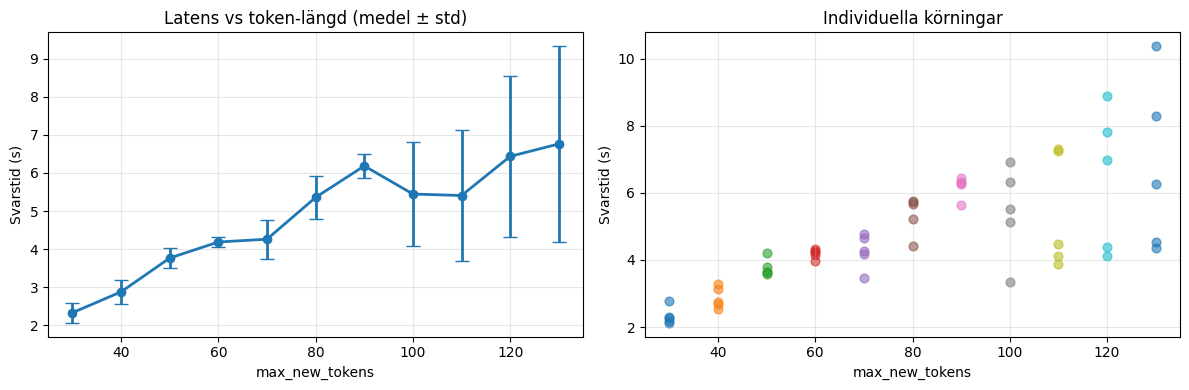

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Vänster: svarstid med felstaplar
axes[0].errorbar(
    summary['max_new_tokens'],
    summary['mean_s'],
    yerr=summary['std_s'],
    marker='o', capsize=5, linewidth=2
)
axes[0].set_xlabel('max_new_tokens')
axes[0].set_ylabel('Svarstid (s)')
axes[0].set_title('Latens vs token-längd (medel ± std)')
axes[0].grid(True, alpha=0.3)

# Höger: alla individuella körningar
for tokens in TOKEN_LENGTHS:
    subset = df[df['max_new_tokens'] == tokens]
    axes[1].scatter(
        [tokens] * len(subset),
        subset['elapsed_s'],
        alpha=0.6, s=40
    )
axes[1].set_xlabel('max_new_tokens')
axes[1].set_ylabel('Svarstid (s)')
axes[1].set_title('Individuella körningar')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()